# Sesión 2 · KDE: del punto a una superficie
**16 de septiembre · 120 minutos.** Objetivos: normalizar KDE, derivar el compromiso sesgo–varianza,
elegir ancho de banda sin test e interpretar masas espaciales. Leer la sección 4 de las notas.

In [1]:
from pathlib import Path
import sys, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from threadpoolctl import threadpool_limits

# Funciona desde la raíz, desde esta carpeta o desde docente/.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'datasets/semana-08').is_dir())
sys.path.insert(0, str(ROOT / 'notebooks/semana-08'))
from movilidad import (load_data, setup, savefig, save_table, spatial_axes,
                       ellipses, safe_silhouette, density_grid, COLORS, DATA)
setup()
threadpool_limits(limits=2)
frame = load_data()
X = frame[['x_km', 'y_km']].to_numpy()
print(f'Desarrollo: {len(frame):,} recogidas. Unidades: km. Semilla: 42.')
print('Test temporal cerrado hasta congelar el modelo.')
display(frame.head(3))

Desarrollo: 6,000 recogidas. Unidades: km. Semilla: 42.
Test temporal cerrado hasta congelar el modelo.


,source_row,pickup_datetime,pickup_longitude,pickup_latitude,x_km,y_km,fare_amount,passenger_count,dropoff_longitude,dropoff_latitude
0,32038,2014-01-01 00:01:00+00:00,-73.991493,40.735202,0.156182,-0.148260,5.5,5,-74.001727,40.727767
1,132584,2014-01-01 00:29:37+00:00,-74.008090,40.740434,-1.251817,0.416562,8.0,2,-73.996088,40.726627
2,190530,2014-01-01 00:54:07+00:00,-73.981944,40.778096,0.907251,4.622599,7.5,1,-73.967887,40.801430


## 1. Un kernel por observación
$$\widehat f_h(x)=\frac{1}{nh^d}\sum_i K((x-x_i)/h).$$
El cambio $u=(x-x_i)/h$ tiene jacobiano $h^d$: cada término integra $1/n$.
En 2D, la densidad está en km$^{-2}$. Una densidad puede superar uno; la integral sobre una región es una probabilidad.
Para kernel simétrico y densidad suave: sesgo $O(h^2)$, varianza $O((nh^d)^{-1})$.

### Para resolver

Con $x=(-1,0,1)$ y kernel gaussiano, calcule $\widehat f_h(0)$ para $h=0.5,1,2$. ¿Debe decrecer siempre la altura de KDE en cualquier punto al aumentar h?

**Mi respuesta y evidencia:**

Calculamos la densidad estimada por KDE en el origen $x=0$ para una muestra unidimensional $x_i \in \{-1, 0, 1\}$ ($n=3, d=1$) con kernel gaussiano estándar $K(u) = \frac{1}{\sqrt{2\pi}} e^{-u^2/2}$.

### 1. Formulación analítica
$$\widehat{f}_h(0) = \frac{1}{n h} \sum_{i=1}^n K\left(\frac{0 - x_i}{h}\right) = \frac{1}{3 h \sqrt{2\pi}} \left[ K\left(\frac{1}{h}\right) + K(0) + K\left(-\frac{1}{h}\right) \right]$$
Dado que $K(u)$ es par, $K(1/h) = K(-1/h) = e^{-1/(2h^2)}$, y $K(0) = 1$:
$$\widehat{f}_h(0) = \frac{1}{3 h \sqrt{2\pi}} \left( 1 + 2 \exp\left(-\frac{1}{2h^2}\right) \right)$$

### 2. Cálculos para cada ancho de banda ($h$)
- **Para $h = 0.5$:**
  $2h^2 = 2(0.25) = 0.5 \implies -\frac{1}{2h^2} = -2$.
  $e^{-2} \approx 0.13533528$.
  $3 h \sqrt{2\pi} = 1.5 \sqrt{2\pi} \approx 3.7599424$.
  $$\widehat{f}_{0.5}(0) = \frac{1 + 2(0.13533528)}{3.7599424} = \frac{1.27067056}{3.7599424} \approx \mathbf{0.337950}\text{ km}^{-1}$$

- **Para $h = 1.0$:**
  $2h^2 = 2(1) = 2 \implies -\frac{1}{2h^2} = -0.5$.
  $e^{-0.5} \approx 0.60653066$.
  $3 h \sqrt{2\pi} = 3 \sqrt{2\pi} \approx 7.5198848$.
  $$\widehat{f}_{1.0}(0) = \frac{1 + 2(0.60653066)}{7.5198848} = \frac{2.21306132}{7.5198848} \approx \mathbf{0.294295}\text{ km}^{-1}$$

- **Para $h = 2.0$:**
  $2h^2 = 2(4) = 8 \implies -\frac{1}{2h^2} = -0.125$.
  $e^{-0.125} \approx 0.8824969$.
  $3 h \sqrt{2\pi} = 6 \sqrt{2\pi} \approx 15.0397696$.
  $$\widehat{f}_{2.0}(0) = \frac{1 + 2(0.8824969)}{15.0397696} = \frac{2.7649938}{15.0397696} \approx \mathbf{0.183845}\text{ km}^{-1}$$

### 3. ¿Debe decrecer siempre la altura de KDE en cualquier punto al aumentar $h$?
**NO.**
La densidad en un punto $x$ no decrece universalmente con $h$. Al aumentar $h$, el kernel se dispersa (aumenta su varianza), lo cual suaviza y aplana la distribución:
- En los **picos o zonas de alta concentración** (como en $x=0$, donde hay una observación exacta y dos vecinas simétricas), la densidad efectivamente disminuye porque la masa local se distribuye hacia afuera.
- Sin embargo, en **valles intermedios, regiones vacías o puntos alejados de los datos** (por ejemplo, en $x=4$), la densidad con un $h$ pequeño es prácticamente cero ($e^{-(4/0.1)^2/2} \approx 0$), mientras que al aumentar $h$ a $2$ o $3$, la cola ancha del kernel alcanza dicho punto, **haciendo que la densidad estimada aumente**.
La integral total sobre todo el espacio siempre permanece constante e igual a 1; aumentar $h$ transfiere masa de las zonas de alta densidad a las zonas de baja densidad.

- **Unidades:** En 1D, $\text{km}^{-1}$ (en 2D espacial corresponde a $\text{km}^{-2}$).
- **Limitación:** El cálculo asume kernel continuo sin efectos de frontera en los bordes del dominio de soporte.

h=0.08: integral aproximada=1.000000
h=0.3: integral aproximada=1.000000
h=1.2: integral aproximada=0.999964


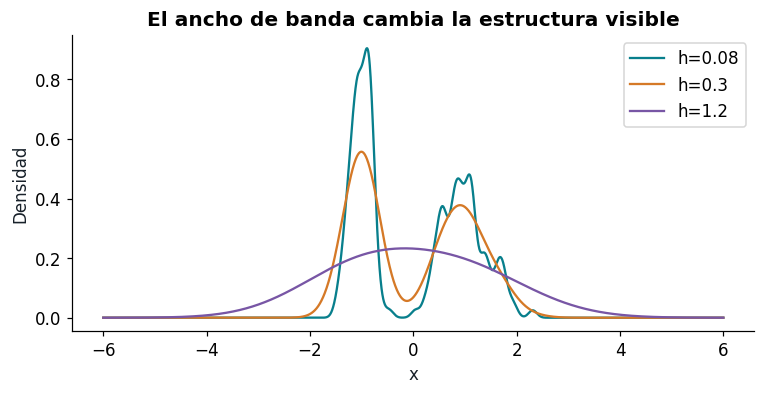

In [2]:
from sklearn.neighbors import KernelDensity
from scipy.integrate import trapezoid
rng = np.random.default_rng(42)
z = np.r_[rng.normal(-1,.25,100),rng.normal(1,.45,100)][:,None]
line = np.linspace(-6,6,3000)
fig, ax = plt.subplots(figsize=(8,3.5))
for h in [.08,.3,1.2]:
    model = KernelDensity(bandwidth=h).fit(z)
    density = np.exp(model.score_samples(line[:,None]))
    ax.plot(line,density,label=f'h={h}')
    integral = trapezoid(density,line)
    print(f'h={h}: integral aproximada={integral:.6f}')
    assert abs(integral-1)<.002
ax.set(xlabel='x',ylabel='Densidad',title='El ancho de banda cambia la estructura visible'); ax.legend()
savefig(fig,'06_bandwidth_1d')

## 2. Derivar y después elegir
En una aproximación interior:
$$\mathrm{AMISE}(h)=A h^4+\frac{B}{nh^d}.$$
Derivar respecto de $h$ da $4Ah^3-dB/(nh^{d+1})=0$ y $h\propto n^{-1/(d+4)}$.
Los términos constantes dependen del kernel y de la densidad desconocida. No es una regla universal de ancho de banda.

Usamos tres particiones temporales expansivas dentro de enero–septiembre. Cada KDE se ajusta solo con el
pasado del fold y se evalúa sobre el bloque siguiente. La puntuación es la media de log-densidades por observación.

,h,mean,std
0,0.1,-6.533944,1.612648
1,0.2,-4.327298,0.352372
2,0.4,-3.897100,0.060777
3,0.8,-3.992702,0.049093
4,1.6,-4.323260,0.047025
5,3.2,-4.940892,0.042710


Ancho congelado (km): 0.4


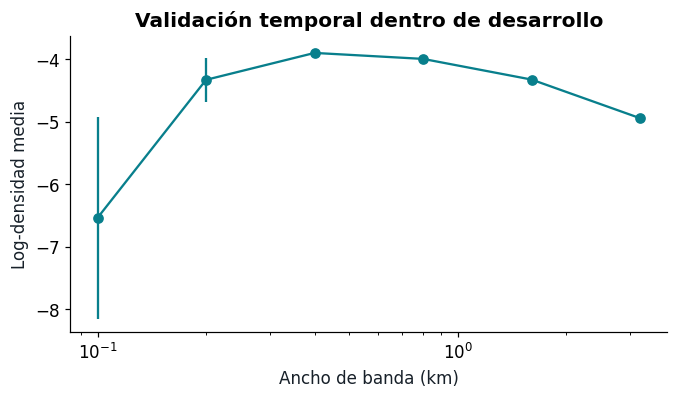

In [3]:
from sklearn.model_selection import TimeSeriesSplit
bandwidths = [.1,.2,.4,.8,1.6,3.2]
folds = list(TimeSeriesSplit(n_splits=3).split(X))
rows = []
for h in bandwidths:
    for fold,(train,validation) in enumerate(folds,1):
        assert frame.iloc[train].pickup_datetime.max() <= frame.iloc[validation].pickup_datetime.min()
        model = KernelDensity(bandwidth=h,kernel='gaussian').fit(X[train])
        rows.append(dict(h=h,fold=fold,mean_log_density=model.score_samples(X[validation]).mean(),
                         n_train=len(train),n_validation=len(validation)))
scores = pd.DataFrame(rows)
cv = scores.groupby('h').mean_log_density.agg(['mean','std']).reset_index()
display(cv)
best_h = float(cv.loc[cv['mean'].idxmax(),'h'])
kde = KernelDensity(bandwidth=best_h,kernel='gaussian').fit(X)
save_table(scores,'kde_folds'); save_table(cv,'kde_seleccion')
print('Ancho congelado (km):',best_h)
fig,ax = plt.subplots(figsize=(7,3.5))
ax.errorbar(cv.h,cv['mean'],yerr=cv['std'],fmt='o-'); ax.set_xscale('log')
ax.set(xlabel='Ancho de banda (km)',ylabel='Log-densidad media',title='Validación temporal dentro de desarrollo')
savefig(fig,'07_kde_cv')

### Para resolver

¿Por qué no comparar score(X) de modelos ajustados con distintos n sin normalizar? ¿Por qué no usar la altura del pico para elegir h?

**Mi respuesta y evidencia:**

1. **¿Por qué no comparar `score(X)` entre distintos $n$ sin normalizar?**
   El método `score(X)` de scikit-learn calcula la suma total de log-densidades sobre el conjunto evaluado: $\sum_{i=1}^n \log \widehat{f}(x_i)$.
   - Esta suma es directamente proporcional al tamaño de la muestra $n$. Si comparamos un fold con $n_1 = 2\,000$ frente a uno con $n_2 = 4\,000$, el segundo tendrá una magnitud de suma sustancialmente más negativa simplemente porque contiene el doble de sumandos, aun cuando la densidad promedio por observación sea superior.
   - Para realizar una comparación controlada y matemáticamente válida, es indispensable normalizar dividiendo por el tamaño de muestra correspondiente: $\frac{1}{n} \sum_{i=1}^n \log \widehat{f}(x_i)$ (log-densidad media por punto), garantizando que las unidades y escalas sean estrictamente comparables.

2. **¿Por qué no usar la altura del pico para elegir $h$?**
   - Si seleccionáramos $h$ para maximizar la altura del pico en las observaciones muestrales, el criterio elegiría trivialmente $h \to 0$. Cuando $h \to 0$, cada kernel gaussiano colapsa a una delta de Dirac centrada exactamente en cada punto muestral, provocando que la altura $\widehat{f}(x_i) \propto \frac{1}{n h^d} \to +\infty$.
   - Esto representaría un **sobreajuste patológico extremo (overfitting)**: el modelo memorizaría los datos observados otorgándoles probabilidad infinita y asignaría densidad exactamente cero a cualquier punto infinitesimalmente cercano, destruyendo toda capacidad de generalización espacial.
   - La selección de $h$ debe buscar el balance óptimo del error cuadrático medio integrado (AMISE), donde el sesgo crece con $h^2$ y la varianza crece con $(n h^d)^{-1}$.

- **Unidades:** Log-densidad media en nats por observación (densidad en $\text{km}^{-2}$).
- **Limitación:** La validación temporal evalúa capacidad predictiva hacia adelante, pero asume que el régimen general de viajes conserva estabilidad macroscópica en el tiempo.

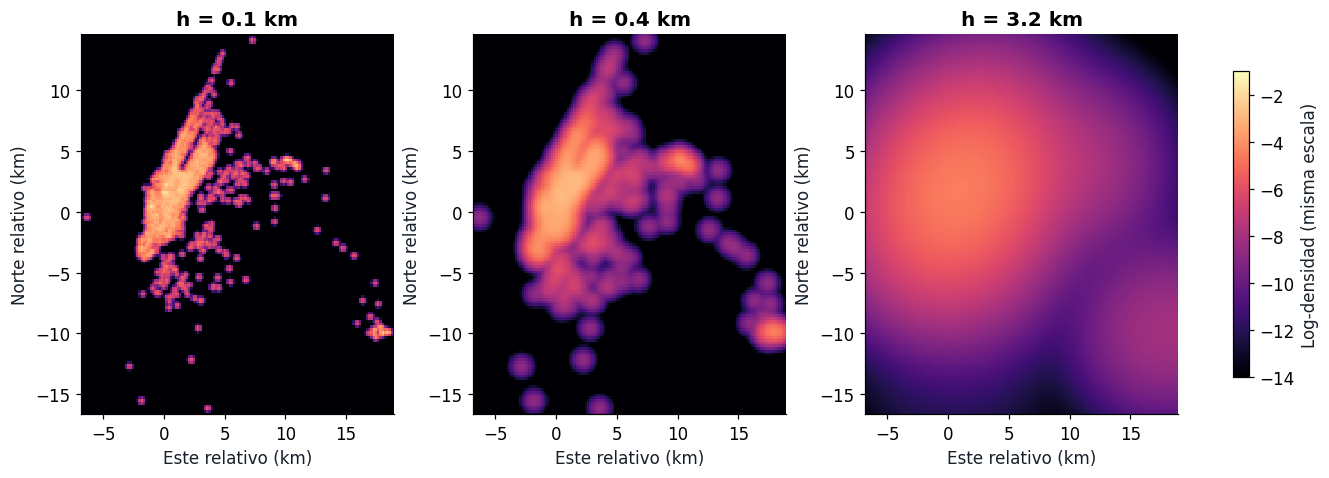

In [4]:
xx,yy,grid = density_grid(X)
fig,axes = plt.subplots(1,3,figsize=(12,4.5),layout='constrained')
for ax,h in zip(axes,[.1,best_h,3.2]):
    model=KernelDensity(bandwidth=h).fit(X)
    log_density=model.score_samples(grid).reshape(xx.shape)
    contour=ax.pcolormesh(xx,yy,log_density,shading='auto',cmap='magma',vmin=-14,vmax=-1)
    spatial_axes(ax,X,f'h = {h:g} km')
fig.colorbar(contour,ax=list(axes),label='Log-densidad (misma escala)',shrink=.65)
savefig(fig,'08_kde_espacial')

## 3. Kernel y soporte
Epanechnikov tiene soporte compacto: fuera de los discos de radio h la densidad es cero y su logaritmo es
menos infinito. Eso puede penalizarlo severamente en validación temporal. Aquí lo comparamos visualmente,
sin ocultar ceros ni escogerlo a partir del test. Ni GMM ni esta KDE conocen ríos o calles.

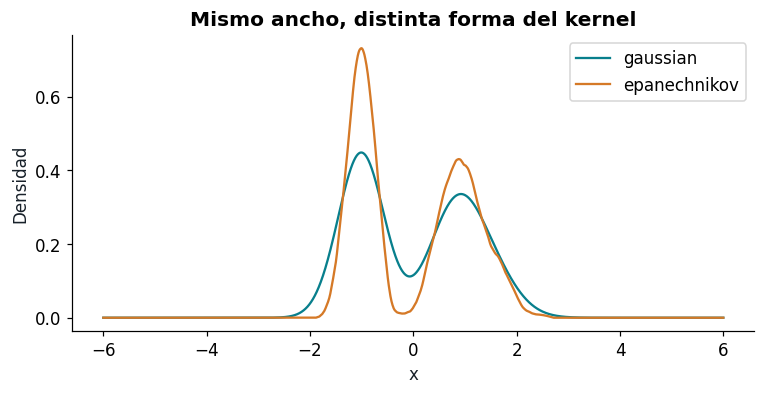

Masa KDE en [-3,3] × [-4,4] km: 0.7263539672486751
Fracción empírica: 0.735


In [5]:
fig,ax=plt.subplots(figsize=(8,3.5))
for kernel in ['gaussian','epanechnikov']:
    model=KernelDensity(bandwidth=.4,kernel=kernel).fit(z)
    ax.plot(line,np.exp(model.score_samples(line[:,None])),label=kernel)
ax.set(xlabel='x',ylabel='Densidad',title='Mismo ancho, distinta forma del kernel'); ax.legend()
savefig(fig,'09_kernels')
# Región fija de ejemplo, expresada en las mismas coordenadas relativas del modelo.
rx=np.linspace(-3,3,220); ry=np.linspace(-4,4,220)
rxx,ryy=np.meshgrid(rx,ry)
values=np.exp(kde.score_samples(np.c_[rxx.ravel(),ryy.ravel()])).reshape(rxx.shape)
mass=trapezoid(trapezoid(values,rx,axis=1),ry)
assert 0<=mass<=1.001
print('Masa KDE en [-3,3] × [-4,4] km:',mass)
print('Fracción empírica:',np.mean((abs(X[:,0])<=3)&(abs(X[:,1])<=4)))

## 4. Comparación temporal final con GMM
El cuaderno reproduce la selección BIC únicamente con desarrollo, sin depender de tablas de una ejecución
anterior. No consulta test para elegir ni requiere haber ejecutado otro cuaderno.

In [6]:
from sklearn.mixture import GaussianMixture
candidates=[]
for covariance in ['full','diag']:
    for k in range(1,9):
        m=GaussianMixture(k,covariance_type=covariance,n_init=5,max_iter=400,
                          reg_covar=1e-5,random_state=42).fit(X)
        candidates.append(dict(k=k,covariance=covariance,bic=m.bic(X),converged=m.converged_))
selection=pd.DataFrame(candidates)
row=selection[selection.converged].sort_values('bic').iloc[0]
gmm=GaussianMixture(int(row.k),covariance_type=row.covariance,n_init=5,max_iter=400,
                    reg_covar=1e-5,random_state=42).fit(X)
test=load_data('test'); Xt=test[['x_km','y_km']].to_numpy()
comparison=[]
for name,model in [('GMM',gmm),('KDE',kde)]:
    logp=model.score_samples(Xt)
    comparison.append(dict(model=name,mean_log_density=float(logp.mean()),n=len(Xt)))
    print(name,'por mes:',pd.Series(logp).groupby(test.pickup_datetime.dt.month).mean().to_dict())
comparison=pd.DataFrame(comparison)
display(comparison); save_table(comparison,'densidad_test_comparacion')

GMM por mes: {10: -3.697354171731579, 11: -3.733753144219047, 12: -3.7436703467938517}


KDE por mes: {10: -3.7589843664170854, 11: -3.76792211150625, 12: -3.8329555324326736}


,model,mean_log_density,n
0,GMM,-3.723905,7311
1,KDE,-3.785522,7311


### Para resolver

Ticket: explique por qué densidad, masa en un área y número de vehículos necesarios son tres cantidades diferentes.

**Mi respuesta y evidencia (Ticket de Salida · Miércoles):**

Estas tres cantidades pertenecen a dimensiones conceptuales, matemáticas y operativas totalmente distintas:

1. **Densidad puntual ($\widehat{f}(x)$):**
   - *Definición*: Es una función matemática intensiva local de probabilidad por unidad de área.
   - *Unidades*: $\text{km}^{-2}$ (en el plano bidimensional).
   - *Propiedades*: Puede tomar valores mayores a 1 (por ejemplo, en el centro hiperdenso de Manhattan, $f(x)$ supera holgadamente $1.5\text{ km}^{-2}$). La probabilidad de una ubicación puntual exacta continua es cero ($P(X=x_0) = 0$).

2. **Masa en una región geográfica ($\int_A \widehat{f}(x) \, dx$):**
   - *Definición*: Es la integral espacial de la densidad sobre un polígono o área $A$. Representa una probabilidad acumulada extensa.
   - *Unidades*: Adimensional (número puro en el intervalo $[0, 1]$).
   - *Propiedades*: Indica la fracción esperada de recogidas que caerán dentro de la región $A$. Se estima mediante cuadratura numérica (regla del trapecio o Riemann sobre una rejilla con ponderación por el área del diferencial de celda $dx\,dy$). No mide volumen de viajes absolutos sin multiplicarse por la demanda total del sistema.

3. **Número de vehículos necesarios ($N_{\text{vehículos}}$):**
   - *Definición*: Es una magnitud operativa y logística discreta (unidades físicas de vehículos/flota).
   - *Unidades*: Vehículos (número entero $\in \mathbb{N}$).
   - *Propiedades*: Para determinar el número de vehículos requeridos en una zona, la masa probabilística no basta. Se requiere información externa que este conjunto de datos **NO contiene**: demanda absoluta de pasajeros en la franja horaria pico, tiempo de ciclo de servicio (duración de viaje + retorno + congestión vial), política de nivel de servicio (tiempo máximo de espera tolerado), tasa de rotación y disponibilidad de infraestructura física de recarga o estacionamiento.

- **Limitación:** Interpretar un mapa de alta densidad KDE como una orden inmediata de despliegue de flota incurre en un grave error de planeación, al ignorar la duración de los viajes, el tráfico vial y la demanda total no capturada.

## Fuentes y reproducción
- Microcurrículo y guía docente ML2, sesiones 19–24; adaptación del cuaderno histórico del profesor.
- [GMM](https://scikit-learn.org/stable/modules/mixture.html), [KDE](https://scikit-learn.org/stable/modules/density.html), [clustering](https://scikit-learn.org/stable/modules/clustering.html).
- Dataset suministrado por el docente; ver `datasets/semana-08/README.md` y `manifest.json`.
- Dependencias fijadas en `requirements-week8.txt`. Inicie el kernel en una carpeta del paquete.